# GRN Case 01: CHD Subtype Regulatory Programs

This notebook uses Navigo to analyze how CHD-associated genes perturb developmental programs in first heart field progenitors.

In this notebook you will:
1. Simulate CHD gene knockouts and quantify transcriptomic response vectors.
2. Identify functional modules linked to cardiac, vascular, embryonic, and neuronal programs.
3. Compare subtype-specific patterns for outflow tract defects, atrial septal defects, and ventricular septal defects.


Import required packages and set deterministic seeds.

In [1]:
import os
import sys
import json
import shutil
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import anndata
import torch

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from IPython.display import display, Image as IPyImage, Markdown

np.random.seed(0)
torch.manual_seed(0)


Set paths and runtime configuration for this GRN CHD case.

In [2]:
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'docs' / 'tutorials').exists() and (p / 'navigo').exists():
            return p
    raise RuntimeError(f'Could not locate repository root from {start}')


cwd = Path.cwd().resolve()
repo_root = find_repo_root(cwd)
tutorials_root = repo_root / 'docs' / 'tutorials'
notebook_dir = tutorials_root / 'notebooks' / 'grn_section'
data_root = repo_root / 'data' / 'grn'
shared_data_root = repo_root / 'data' / 'shared'

grn_script_sources = {
    'run_umap.py': repo_root / 'navigo' / 'grn_run_umap.py',
    'plot_umap.py': repo_root / 'navigo' / 'grn_plot_umap.py',
    'analyze_chd_distance.py': repo_root / 'navigo' / 'grn_analyze_chd_distance.py',
    'plot_chd_distance.py': repo_root / 'navigo' / 'grn_plot_chd_distance.py',
    'analyze_chd_distribution.py': repo_root / 'navigo' / 'grn_analyze_chd_distribution.py',
    'plot_umap_interaction_v3.py': repo_root / 'navigo' / 'grn_plot_umap_interaction_v3.py',
    'pathway_enrichment.py': repo_root / 'navigo' / 'grn_pathway_enrichment.py',
    'analyze_chd_clean.py': repo_root / 'navigo' / 'grn_analyze_chd_clean.py',
    'analyze_chd_clean_dynamo.py': repo_root / 'navigo' / 'grn_analyze_chd_clean_dynamo.py',
}

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from navigo import run_perturbation_inference
from navigo.model import MLPTimeGRN, Navigo

DATA_PATH = shared_data_root / 'mouse_heart_fibroblasts.h5ad'
CHECKPOINT_PATH = repo_root / 'checkpoints' / 'grn' / 'grn_checkpoint_heart.pth'
GENE_CLASS_PATH = data_root / 'gene_classification_summary.csv'
MSIGDB_PATH = data_root / 'msigdb_mouse_v2025_1.json'
DYNAMO_JAC_PATH = data_root / 'jacobian_dynamo.csv'
TF_LIST_PATH = data_root / 'mouse_tf_list_in_data.csv'
DEG_PATH = data_root / 'atrial_vs_ventricular_deg.csv'

CELL_TYPE = 'First heart field'
CELL_TYPE_TAG = 'First_heart_field'
KO_MULTIPLIER = 0.0
FLOW_NUM_STEPS = 100
SIMULATION_STEPS = 10
HIDDEN_1 = 5012
HIDDEN_2 = 5012
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

OUT_ROOT = tutorials_root / 'outputs' / 'grn_chd_analysis'
RAW_OUT = OUT_ROOT / 'inference_raw'
RESULT_TABLE_DIR = OUT_ROOT / 'results'
TMP_DIR = OUT_ROOT / 'tmp'
SUMMARY_WS = OUT_ROOT / 'paper_style_workspace'
FIG_DIR = OUT_ROOT / 'figures'

for d in [OUT_ROOT, RAW_OUT, RESULT_TABLE_DIR, TMP_DIR, SUMMARY_WS, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

required = {
    'data': DATA_PATH,
    'checkpoint': CHECKPOINT_PATH,
    'gene_classification': GENE_CLASS_PATH,
    'msigdb': MSIGDB_PATH,
    'dynamo_jacobian': DYNAMO_JAC_PATH,
    'tf_list': TF_LIST_PATH,
    'deg_file': DEG_PATH,
}
missing = [f'{k}: {v}' for k, v in required.items() if not v.exists()]
if missing:
    raise FileNotFoundError('Missing required files\n' + '\n'.join(missing))

missing_scripts = [name for name, path in grn_script_sources.items() if not path.exists()]
if missing_scripts:
    raise FileNotFoundError('Missing GRN helper scripts in navigo/: ' + ', '.join(missing_scripts))


Prepare the first heart field subset and CHD target gene list. CHD genes are taken from the curated CHDgene-based input used in the project assets.

In [3]:

adata = anndata.read_h5ad(DATA_PATH)

if 'gene_name' in adata.var.columns:
    adata.var['gene_name'] = adata.var['gene_name'].astype(str)
elif 'gene_short_name' in adata.var.columns:
    adata.var['gene_name'] = adata.var['gene_short_name'].astype(str)
else:
    adata.var['gene_name'] = adata.var_names.astype(str)

adata_subset = adata[adata.obs['cell_type'].astype(str) == CELL_TYPE].copy()
if adata_subset.n_obs == 0:
    raise ValueError(f'No cells found for {CELL_TYPE!r}')

adata_subset.obs['cell_type'] = 'SelectedCells'
subset_h5ad_path = TMP_DIR / 'subset_for_chd_inference.h5ad'
adata_subset.write_h5ad(subset_h5ad_path)

cls_df = pd.read_csv(GENE_CLASS_PATH)
target_genes = cls_df['Gene'].astype(str).str.strip().dropna().unique().tolist()

target_list_txt_path = TMP_DIR / 'chd_target_list.txt'
target_list_txt_path.write_text('\n'.join(target_genes) + '\n')

print('Subset shape    :', adata_subset.shape)
print('Num CHD targets :', len(target_genes))


Subset shape    : (4303, 3902)
Num CHD targets : 58


## Step 1: Simulate CHD gene knockout responses
For each CHD gene, perturbation is simulated by setting expression to zero and comparing predicted perturbed vs wild-type trajectories to obtain a response vector.

In [ ]:
input_dim = int(adata_subset.n_vars * 2)
existing_summary_path = RAW_OUT / 'inference_summary.json'
existing_result_csvs = sorted(RESULT_TABLE_DIR.glob('*_neg0.0x_knockout_First_heart_field.csv'))

if existing_summary_path.exists() and len(existing_result_csvs) >= len(target_genes):
    inference_summary = json.loads(existing_summary_path.read_text())
else:
    inference_summary = run_perturbation_inference(
        data_path=subset_h5ad_path,
        checkpoint_path=CHECKPOINT_PATH,
        target_list_path=target_list_txt_path,
        output_dir=RAW_OUT,
        fibro_cell_type='SelectedCells',
        input_dim=input_dim,
        hidden_1=HIDDEN_1,
        hidden_2=HIDDEN_2,
        flow_num_steps=FLOW_NUM_STEPS,
        simulation_steps=SIMULATION_STEPS,
        knockout_scale=KO_MULTIPLIER,
        device=DEVICE,
        strict_target_presence=False,
    )

    ms = np.asarray(adata_subset.layers['Ms'])
    mu = np.asarray(adata_subset.layers['Mu'])
    data_np = np.concatenate([ms, mu], axis=1)
    data_np = (data_np - data_np.min(axis=0)) / (data_np.max(axis=0) - data_np.min(axis=0) + 1e-7)

    data_t = torch.tensor(data_np, dtype=torch.float32).to(DEVICE)
    time_t = torch.tensor(np.asarray(adata_subset.obs['time'], dtype=np.float32), dtype=torch.float32).to(DEVICE)

    model = MLPTimeGRN(input_dim=input_dim, hidden_1=HIDDEN_1, hidden_2=HIDDEN_2).to(DEVICE)
    state = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    model.load_state_dict(state, strict=True)
    flow = Navigo(model=model, num_steps=FLOW_NUM_STEPS, device=DEVICE)

    pred_base = flow.sample_ode_time_interval(
        z_full=data_t,
        t_start=time_t,
        t_end=time_t + 1,
        N=SIMULATION_STEPS,
    )

    half = input_dim // 2
    gene_names = list(adata_subset.var['gene_name'].astype(str).values)
    wt_total_expr_values = pred_base.mean(axis=0)[:half] + pred_base.mean(axis=0)[half:]

    wt_total_expr_map = {}
    for g, v in zip(gene_names, wt_total_expr_values):
        if g not in wt_total_expr_map:
            wt_total_expr_map[g] = float(v)

    mult_str = f'neg{abs(KO_MULTIPLIER)}x'
    for csv_path in sorted(RAW_OUT.glob('*.csv')):
        if csv_path.name == 'inference_summary.json':
            continue
        target = csv_path.stem
        df = pd.read_csv(csv_path)

        if 'gene_name' not in df.columns and 'gene' in df.columns:
            df = df.rename(columns={'gene': 'gene_name'})

        df['wt_total_expr'] = df['gene_name'].map(wt_total_expr_map).fillna(0.0).astype(float)
        df.loc[df['gene_name'] == target, 'wt_total_expr'] = 0.0

        df['relative_change'] = np.where(df['wt_total_expr'] != 0, df['total_change'] / (df['wt_total_expr'] + 1e-7), 0.0)
        df = df.sort_values('total_change', key=lambda s: np.abs(s), ascending=False).copy()

        out_df = df[['gene_name', 'spliced_change', 'unspliced_change', 'total_change', 'relative_change', 'wt_total_expr']].rename(columns={'gene_name': 'gene'})
        out_name = f'{target}_{mult_str}_knockout_{CELL_TYPE_TAG}.csv'
        out_df.to_csv(RESULT_TABLE_DIR / out_name, index=False)

print(f'Target genes: {len(target_genes)}')
print(f"Inference CSV files: {len(list(RAW_OUT.glob('*.csv')))}")
print(f"Summary table files: {len(list(RESULT_TABLE_DIR.glob('*_neg0.0x_knockout_First_heart_field.csv')))}")
print(f'Output folder: {OUT_ROOT.relative_to(repo_root)}')


## Step 2: Generate GRN summary figures
Create summary figures for module organization, disease-subtype structure, regulatory interactions, pathway enrichment, and chamber-biased marker effects.

In [5]:
def run_py(script_path, cwd):
    cmd = ['python', script_path]
    proc = subprocess.run(cmd, cwd=cwd, capture_output=True, text=True)
    if proc.returncode != 0:
        if proc.stdout.strip():
            print(proc.stdout[-1000:])
        print(proc.stderr)
        raise RuntimeError(f'Failed: {script_path} in {cwd}')

expected_outputs = [
    FIG_DIR / 'fig3d_umap.png',
    FIG_DIR / 'fig3e_chd_distance.png',
    FIG_DIR / 'fig3f_chd_distribution.png',
    FIG_DIR / 'fig3g_interaction_network.pdf',
    FIG_DIR / 'fig3h_ot_pathway.png',
    FIG_DIR / 'fig3j_examples.png',
]

if not all(path.exists() for path in expected_outputs):
    for sub in ['Panel_UMAP', 'Panel_pathway_enrichment', 'Panel_barplot', 'results']:
        (SUMMARY_WS / sub).mkdir(parents=True, exist_ok=True)
    (SUMMARY_WS / 'Panel_pathway_enrichment' / 'pathway_enrichment').mkdir(parents=True, exist_ok=True)

    for f in RESULT_TABLE_DIR.glob('*_neg0.0x_knockout_First_heart_field.csv'):
        shutil.copy2(f, SUMMARY_WS / 'results' / f.name)

    asset_sources = {
        'gene_classification_summary.csv': GENE_CLASS_PATH,
        'msigdb.v2025.1.Mm.json': MSIGDB_PATH,
        'jacobian_dynamo.csv': DYNAMO_JAC_PATH,
        'mouse_tf_list_in_data.csv': TF_LIST_PATH,
    }
    for dest_name, src_path in asset_sources.items():
        shutil.copy2(src_path, SUMMARY_WS / dest_name)

    umap_scripts = [
        'run_umap.py',
        'plot_umap.py',
        'analyze_chd_distance.py',
        'plot_chd_distance.py',
        'analyze_chd_distribution.py',
        'plot_umap_interaction_v3.py',
    ]
    for script_name in umap_scripts:
        shutil.copy2(grn_script_sources[script_name], SUMMARY_WS / 'Panel_UMAP' / script_name)

    shutil.copy2(grn_script_sources['pathway_enrichment.py'], SUMMARY_WS / 'Panel_pathway_enrichment' / 'pathway_enrichment.py')

    for script_name in ['analyze_chd_clean.py', 'analyze_chd_clean_dynamo.py']:
        shutil.copy2(grn_script_sources[script_name], SUMMARY_WS / 'Panel_barplot' / script_name)
    shutil.copy2(DYNAMO_JAC_PATH, SUMMARY_WS / 'Panel_barplot' / 'jacobian_dynamo.csv')
    shutil.copy2(data_root / 'Atrial#cardiomyocytes_Ventricular#cardiomyocytes_deg.csv', SUMMARY_WS / 'Panel_barplot' / 'Atrial#cardiomyocytes_Ventricular#cardiomyocytes_deg.csv')

    def patch_scanpy_script(path):
        txt = Path(path).read_text()
        if 'import scanpy as sc' not in txt:
            return
        shim = (
            "import anndata as _anndata_compat\n"
            "if not hasattr(_anndata_compat, 'read'):\n"
            "    _anndata_compat.read = _anndata_compat.read_h5ad\n"
        )
        if "_anndata_compat.read = _anndata_compat.read_h5ad" not in txt:
            txt = txt.replace('import scanpy as sc', shim + 'import scanpy as sc')
        Path(path).write_text(txt)

    def patch_deterministic_shared_umap(plot_umap_path, interaction_path, run_umap_path):
        for script_path in [plot_umap_path, interaction_path, run_umap_path]:
            txt = Path(script_path).read_text()
            txt = txt.replace(
                'ko_files = glob(f"{ko_path}/*_neg0.0x_knockout_First_heart_field.csv")',
                'ko_files = sorted(glob(f"{ko_path}/*_neg0.0x_knockout_First_heart_field.csv"))',
            )
            Path(script_path).write_text(txt)

        txt = Path(plot_umap_path).read_text()
        if 'umap_embedding.csv' not in txt:
            marker = "    adata = anndata.AnnData(X=response_matrix)"
            insert = (
                "    # Save shared embedding coordinates so downstream plots reuse the same layout.\n"
                "    emb_df = pd.DataFrame({\n"
                "        'gene': gene_names,\n"
                "        'cluster': clusters,\n"
                "        'umap1': response_umap[:, 0],\n"
                "        'umap2': response_umap[:, 1],\n"
                "    })\n"
                "    emb_df.to_csv('umap_embedding.csv', index=False)\n\n"
            )
            txt = txt.replace(marker, insert + marker)
            Path(plot_umap_path).write_text(txt)

        txt = Path(interaction_path).read_text()
        if "embed_path = 'umap_embedding.csv'" not in txt:
            old = (
                "    reducer = umap.UMAP(n_components=2, random_state=42)\n"
                "    response_umap = reducer.fit_transform(response_matrix)\n"
            )
            new = (
                "    embed_path = 'umap_embedding.csv'\n"
                "    if os.path.exists(embed_path):\n"
                "        emb = pd.read_csv(embed_path).set_index('gene')\n"
                "        if set(gene_names).issubset(set(emb.index)):\n"
                "            emb = emb.loc[gene_names]\n"
                "            response_umap = emb[['umap1', 'umap2']].values\n"
                "            clusters = emb['cluster'].astype(int).values\n"
                "        else:\n"
                "            reducer = umap.UMAP(n_components=2, random_state=42)\n"
                "            response_umap = reducer.fit_transform(response_matrix)\n"
                "    else:\n"
                "        reducer = umap.UMAP(n_components=2, random_state=42)\n"
                "        response_umap = reducer.fit_transform(response_matrix)\n"
            )
            txt = txt.replace(old, new)
            Path(interaction_path).write_text(txt)

    for script_path in [
        SUMMARY_WS / 'Panel_UMAP' / 'plot_umap.py',
        SUMMARY_WS / 'Panel_UMAP' / 'plot_umap_interaction_v3.py',
    ]:
        if script_path.exists():
            patch_scanpy_script(script_path)

    patch_deterministic_shared_umap(
        SUMMARY_WS / 'Panel_UMAP' / 'plot_umap.py',
        SUMMARY_WS / 'Panel_UMAP' / 'plot_umap_interaction_v3.py',
        SUMMARY_WS / 'Panel_UMAP' / 'run_umap.py',
    )

    run_py('run_umap.py', SUMMARY_WS / 'Panel_UMAP')
    run_py('plot_umap.py', SUMMARY_WS / 'Panel_UMAP')
    run_py('analyze_chd_distance.py', SUMMARY_WS / 'Panel_UMAP')
    run_py('plot_chd_distance.py', SUMMARY_WS / 'Panel_UMAP')
    run_py('analyze_chd_distribution.py', SUMMARY_WS / 'Panel_UMAP')
    run_py('plot_umap_interaction_v3.py', SUMMARY_WS / 'Panel_UMAP')
    run_py('pathway_enrichment.py', SUMMARY_WS / 'Panel_pathway_enrichment')
    run_py('analyze_chd_clean.py', SUMMARY_WS / 'Panel_barplot')
    run_py('analyze_chd_clean_dynamo.py', SUMMARY_WS / 'Panel_barplot')


In [6]:
FIG_DIR = OUT_ROOT / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

candidates = [
    SUMMARY_WS / 'Panel_UMAP' / 'figures' / 'umapumap_clusters.png',
    SUMMARY_WS / 'Panel_UMAP' / 'figures' / 'umapumap_clusters_no_legend.png',
    SUMMARY_WS / 'Panel_UMAP' / 'interaction_network_v3.pdf',
    SUMMARY_WS / 'Panel_UMAP' / 'cluster_results' / 'chd_cluster_heatmap_final.png',
    SUMMARY_WS / 'Panel_UMAP' / 'cluster_results' / 'chd_cluster_heatmap_v2.png',
    SUMMARY_WS / 'Panel_UMAP' / 'cluster_results' / 'chd_cluster_heatmap.png',
]

for path in candidates:
    if path.exists():
        shutil.copy2(path, FIG_DIR / path.name)


## Step 3: Plot response-vector UMAP
Display the inferred response-vector modules directly from the shared UMAP embedding.


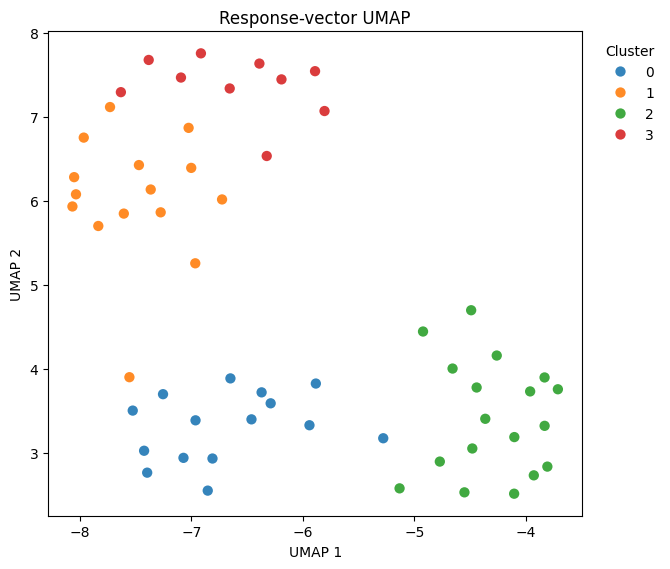

In [7]:
umap_csv = SUMMARY_WS / 'Panel_UMAP' / 'umap_embedding.csv'
if not umap_csv.exists():
    raise FileNotFoundError(umap_csv)

umap_df = pd.read_csv(umap_csv)
fig, ax = plt.subplots(figsize=(6.8, 5.8))
sns.scatterplot(
    data=umap_df,
    x='umap1',
    y='umap2',
    hue='cluster',
    palette='tab10',
    s=55,
    alpha=0.9,
    edgecolor='none',
    ax=ax,
)
ax.set_title('Response-vector UMAP')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend(title='Cluster', frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Step 4: Plot CHD gene distances to cluster centroids
Show how representative CHD genes relate to the learned response modules.


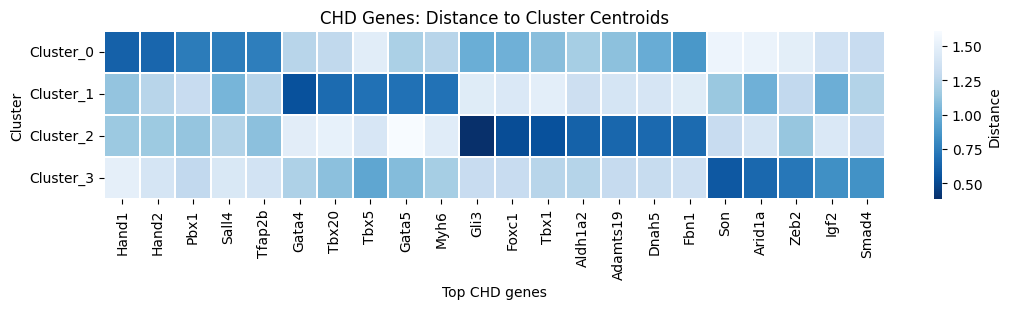

In [8]:
dist_matrix_path = SUMMARY_WS / 'Panel_UMAP' / 'cluster_results' / 'top_genes_distance_matrix.csv'
if not dist_matrix_path.exists():
    raise FileNotFoundError(dist_matrix_path)

dist_df = pd.read_csv(dist_matrix_path, index_col=0)
plt.figure(figsize=(11, 3.2))
sns.heatmap(
    dist_df,
    cmap='Blues_r',
    annot=False,
    linewidths=0.35,
    linecolor='white',
    cbar_kws={'label': 'Distance'},
)
plt.title('CHD Genes: Distance to Cluster Centroids')
plt.xlabel('Top CHD genes')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()


## Step 5: Plot CHD subtype distributions across modules
Compare how different CHD subtype categories populate the inferred response clusters.


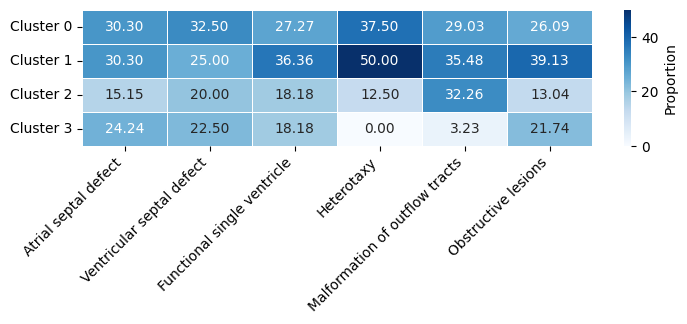

In [9]:
chd_dist_csv = SUMMARY_WS / 'Panel_UMAP' / 'cluster_results' / 'chd_cluster_distribution.csv'
new_gc = SUMMARY_WS / 'Panel_UMAP' / 'cluster_results' / 'gene_clusters.csv'
ref_gc = data_root / 'reference' / 'gene_clusters.csv'
for path in [chd_dist_csv, new_gc, ref_gc]:
    if not path.exists():
        raise FileNotFoundError(path)

from scipy.optimize import linear_sum_assignment
ndf = pd.read_csv(new_gc)
rdf = pd.read_csv(ref_gc)
mm = ndf.merge(rdf, on='gene', suffixes=('_new', '_ref'))
cont = pd.crosstab(mm['cluster_new'], mm['cluster_ref']).reindex(index=range(4), columns=range(4), fill_value=0)
rr, cc = linear_sum_assignment(-cont.values)
c_map = {int(r): int(c) for r, c in zip(rr, cc)}

dist = pd.read_csv(chd_dist_csv, index_col=0)
dist.columns = [c_map.get(int(c), int(c)) for c in dist.columns]
dist = dist.reindex(columns=[0, 1, 2, 3])
plot_df = dist.T
label_map = {
    'ASD': 'Atrial septal defect',
    'VSD': 'Ventricular septal defect',
    'Functional single ventricle': 'Functional single ventricle',
    'Heterotaxy': 'Heterotaxy',
    'Malformation of outflow tracts': 'Malformation of outflow tracts',
    'Obstructive lesions': 'Obstructive lesions',
}
ordered = ['ASD', 'VSD', 'Functional single ventricle', 'Heterotaxy', 'Malformation of outflow tracts', 'Obstructive lesions']
plot_df = plot_df[ordered]
plot_df.columns = [label_map[c] for c in plot_df.columns]
plot_df.index = [f'Cluster {i}' for i in plot_df.index]
plt.figure(figsize=(7.4, 3.4))
sns.heatmap(plot_df, annot=True, fmt='.2f', cmap='Blues', linewidths=0.5, linecolor='white', cbar_kws={'label': 'Proportion'})
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## Step 6: Plot outflow-tract pathway enrichment
Show the pathways most enriched in the outflow-tract defect category.


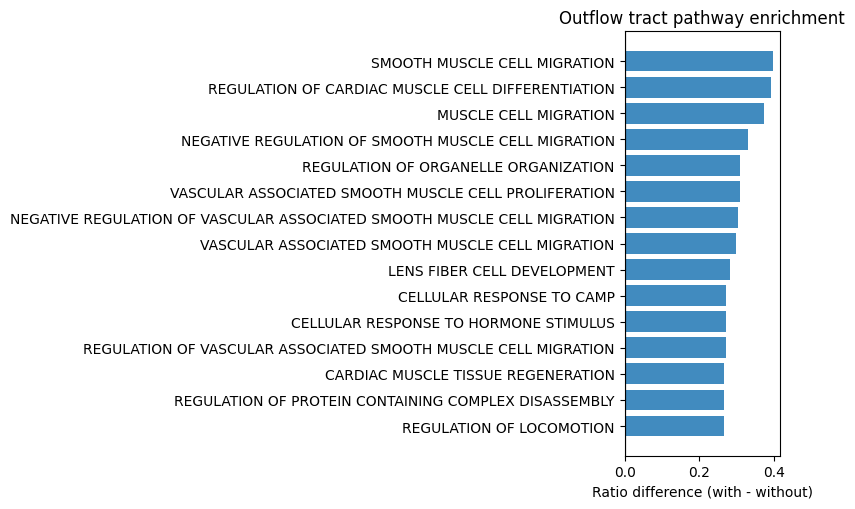

In [10]:
ot_path = SUMMARY_WS / 'Panel_pathway_enrichment' / 'pathway_enrichment' / 'pathway_top30_malformation_of_outflow_tracts.csv'
if not ot_path.exists():
    raise FileNotFoundError(ot_path)

ot = pd.read_csv(ot_path).head(15).iloc[::-1]
plt.figure(figsize=(8, 5.2))
plt.barh(ot['pathway'], ot['ratio_diff'], color=plt.cm.tab20.colors[0], alpha=0.85)
plt.axvline(0, color='black', lw=0.8)
plt.xlabel('Ratio difference (with - without)')
plt.title('Outflow tract pathway enrichment')
plt.tight_layout()
plt.show()


## Step 7: Chamber-specific impact analysis
Test whether ASD genes shift atrial markers and VSD genes shift ventricular markers.


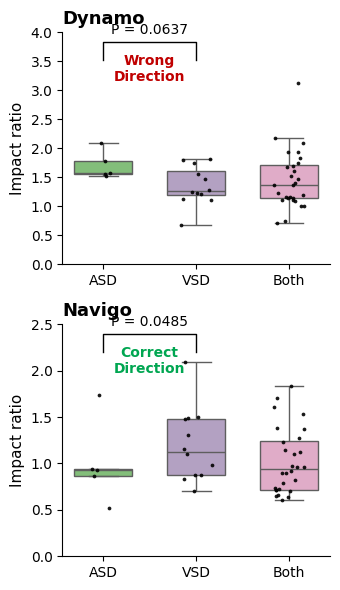

In [11]:
fig3i_explicit = FIG_DIR / 'fig3i_marker_ratio.png'

# Reuse the summary CSVs generated in Step 2.
nav_i_path = SUMMARY_WS / 'Panel_barplot' / 'gene_marker_change_analysis.csv'
dyn_i_path = SUMMARY_WS / 'Panel_barplot' / 'gene_marker_change_analysis_dynamo.csv'

if nav_i_path.exists() and dyn_i_path.exists():
    nav_i = pd.read_csv(nav_i_path)
    dyn_i = pd.read_csv(dyn_i_path)

    order = ['ASD_only', 'VSD_only', 'Both']
    label_map = {'ASD_only': 'ASD', 'VSD_only': 'VSD', 'Both': 'Both'}
    palette = {'ASD': '#7BC96F', 'VSD': '#B39BC8', 'Both': '#E9A3C9'}

    def prep_ratio(df):
        w = df[df['type'].isin(order)].copy()
        w['type_plot'] = w['type'].map(label_map)
        return w

    navp_exp = prep_ratio(nav_i)
    dynp_exp = prep_ratio(dyn_i)

    def draw_panel_explicit(ax, df, title, ylim_max=None, p_label=None):
        sns.boxplot(
            data=df,
            x='type_plot', y='marker_v_to_a_ratio',
            hue='type_plot',
            order=['ASD', 'VSD', 'Both'],
            hue_order=['ASD', 'VSD', 'Both'],
            palette=palette,
            dodge=False,
            fliersize=0,
            linewidth=1.0,
            width=0.62,
            ax=ax,
        )
        if ax.legend_ is not None:
            ax.legend_.remove()
        sns.stripplot(
            data=df,
            x='type_plot', y='marker_v_to_a_ratio',
            order=['ASD', 'VSD', 'Both'],
            color='black', size=2.7, jitter=0.17, alpha=0.9, ax=ax,
        )

        asd = df[df['type_plot'] == 'ASD']['marker_v_to_a_ratio']
        vsd = df[df['type_plot'] == 'VSD']['marker_v_to_a_ratio']
        pval = mannwhitneyu(asd, vsd, alternative='two-sided').pvalue if len(asd) and len(vsd) else np.nan

        y0 = max(df['marker_v_to_a_ratio'].max(), 0)
        if ylim_max is None:
            ylim_max = y0 * 1.35 if y0 > 0 else 1.0
        y = ylim_max * 0.88
        h = ylim_max * 0.08
        ax.plot([0, 0, 1, 1], [y, y + h, y + h, y], color='black', lw=1)
        p_show = p_label if p_label is not None else pval
        ax.text(0.5, y + h + ylim_max * 0.02, f'P = {p_show:.4f}', ha='center', va='bottom', fontsize=10)

        wrong = asd.mean() > vsd.mean()
        ax.text(
            0.5,
            y + h * 0.35,
            'Wrong\nDirection' if wrong else 'Correct\nDirection',
            ha='center', va='top',
            fontsize=10,
            color='#C00000' if wrong else '#00A651',
            fontweight='bold',
        )

        ax.set_title(title, loc='left', fontsize=13, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('Impact ratio', fontsize=11)
        ax.tick_params(axis='both', labelsize=10)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_ylim(0, ylim_max)

    fig, axes = plt.subplots(2, 1, figsize=(3.5, 6.0), sharex=True)
    draw_panel_explicit(axes[0], dynp_exp, 'Dynamo', ylim_max=4.0, p_label=0.0637)
    draw_panel_explicit(axes[1], navp_exp, 'Navigo', ylim_max=2.5, p_label=0.0485)
    axes[0].tick_params(labelbottom=True)
    plt.tight_layout(h_pad=1.0)
    plt.savefig(fig3i_explicit, dpi=300)
    plt.show()
    plt.close(fig)
else:
    print('Figure 3i reconstruction skipped: required Panel_barplot CSV files are missing.')


## How to read the results
- **Response-vector UMAP**: Knockout response vectors separate CHD genes into functional modules.
- **Representative regulators**: Genes closest to each cluster center highlight representative regulators for each module.
- **Subtype composition**: CHD subtype composition across clusters shows mixed genetic architectures; heterotaxy is enriched in neuronal- and cardiac-related modules.
- **Mutual-impact network**: Highly connected hub genes and cross-module coupling become apparent in the inferred interaction structure.
- **Outflow tract pathway enrichment**: Outflow tract defect genes show stronger enrichment in cell-junction, migration, differentiation, and signaling pathways.
- **Chamber-biased marker impact**: Ventricular septal defect genes show stronger ventricular-marker impact, atrial septal defect genes show stronger atrial-marker impact, and genes associated with both defects are intermediate.
- **Example regulatory effects**: Smad3, Gata6, and Myh7 illustrate chamber-biased downstream marker changes.
